# ImpactoSEA-ProPG: Calculadora de Transmissão de Ruído e Vibração em Academias

**Metodologia:** Análise Estatística de Energia (SEA) baseada no guia *ProPG: Gym Acoustics Guidance (2023)*.
**Desenvolvedor:** Engenharia Acústica & Python

---


## Revisao externa aplicada

Esta versao foi editada como revisao tecnica do estudo, usando como base os documentos enviados sobre ProPG/GAG, ProAcustica Academias e metricas de impacto em baixa frequencia.

Principais correcoes aplicadas:

- As Curvas G foram embutidas no notebook a partir da tabela reportada no GAG/ProPG. Implicacao: o notebook deixa de depender da autenticacao do Colab/Google Sheets para classificar os resultados.
- O espectro de calculo foi limitado a 31,5 Hz - 2000 Hz, coerente com o escopo do prompt original e com a faixa usada nos exemplos de predicao revisados. Implicacao: a antiga banda de 5000 Hz nao e mais usada para conclusao do modelo SEA deste estudo.
- O tempo de contato passou a gerar uma frequencia de corte `fc = 1,5 / Tc` e uma correcao espectral de `-12 dB/oitava` acima do corte, equivalente a `-4 dB` por terco de oitava. Implicacao: as bandas acima do corte deixam de ser tratadas como se o impacto tivesse espectro plano ate altas frequencias.
- A atenuacao do piso flutuante nao usa mais 35 dB como teto fixo por banda. O valor padrao foi ajustado para 24 dB, inspirado no caso medido do ProPG para sistema com mola e manta. Implicacao: o resultado mitigado fica menos otimista e mais defensavel para estudo preliminar.
- A soma global de bandas deixou de ser chamada de `Leq`. Implicacao: a saida final agora e uma soma logaritmica de `Lmax` por banda, util para comparacao interna, mas nao para conformidade normativa.


In [39]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.35,
})

print("Notebook revisado carregado. Execute as celulas em ordem para recalcular os resultados.")


Notebook revisado carregado. Execute as celulas em ordem para recalcular os resultados.


## Escopo tecnico da revisao

O notebook continua sendo um estudo de aplicacao do metodo ProPG/GAG, nao um laudo. As alteracoes abaixo corrigem pontos que poderiam distorcer a interpretacao:

1. separar dado de referencia, modelo fisico e criterio de classificacao;
2. registrar avisos quando a densidade modal torna o SEA pouco robusto em baixa frequencia;
3. tratar o tempo de contato como parametro critico e nao como garantia de desempenho;
4. evitar conclusoes de conformidade quando faltam ensaio de impacto, medicao de vibracao e calibracao do sistema real.


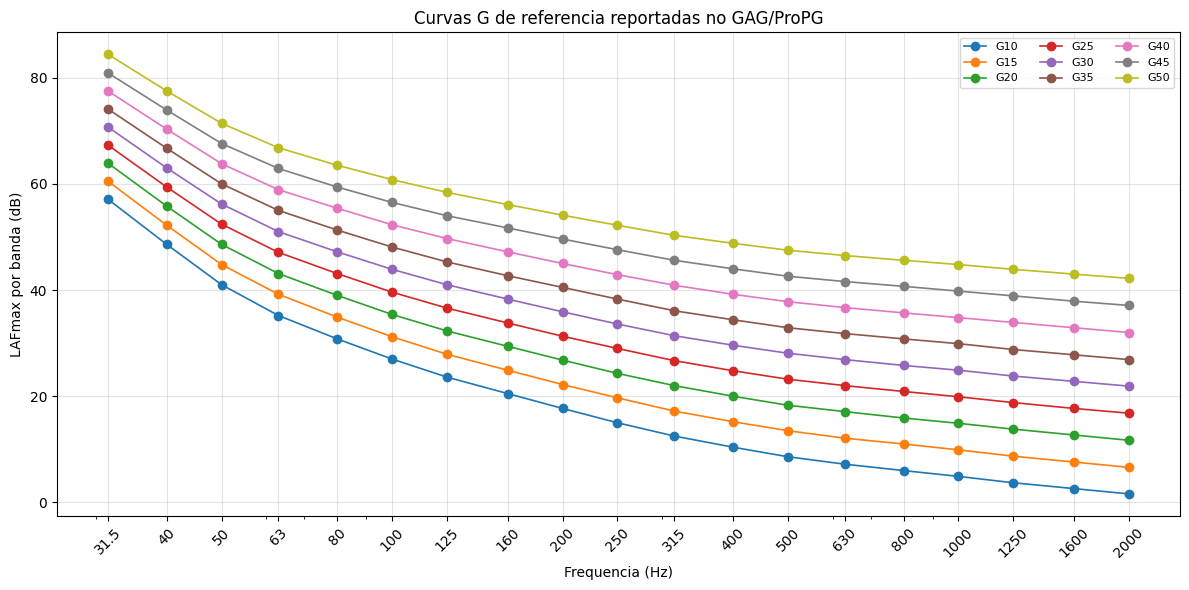

,G-value,31.5,40,50,63,80,100,125,160,200,250,315,400,500,630,800,1000,1250,1600,2000
0,10,57.1,48.6,41.0,35.2,30.8,27.0,23.6,20.5,17.7,15.0,12.5,10.4,8.6,7.2,6.0,4.9,3.7,2.6,1.6
1,15,60.5,52.2,44.8,39.2,34.9,31.2,27.9,24.9,22.2,19.7,17.2,15.2,13.5,12.1,11.0,9.9,8.7,7.6,6.6
2,20,63.9,55.8,48.6,43.1,39.0,35.4,32.3,29.4,26.8,24.3,22.0,20.0,18.3,17.1,15.9,14.9,13.8,12.7,11.7
3,25,67.3,59.4,52.4,47.1,43.1,39.6,36.6,33.8,31.3,29.0,26.7,24.8,23.2,22.0,20.9,19.9,18.8,17.7,16.8
4,30,70.7,63.0,56.2,51.0,47.2,43.9,41.0,38.3,35.9,33.6,31.4,29.6,28.1,26.9,25.8,24.9,23.8,22.8,21.9


In [40]:
# ==============================================================================
# CURVAS G DE REFERENCIA - TABELA REPORTADA NO GAG/PROPG
# ==============================================================================
# Alteracao: a planilha do Google Sheets deixou de ser obrigatoria.
# Implicacao: o notebook fica reprodutivel offline; se a tabela oficial mudar,
# este bloco deve ser atualizado manualmente.

G_CURVES = {
    10: {31.5: 57.1, 40: 48.6, 50: 41.0, 63: 35.2, 80: 30.8, 100: 27.0, 125: 23.6, 160: 20.5, 200: 17.7, 250: 15.0, 315: 12.5, 400: 10.4, 500: 8.6, 630: 7.2, 800: 6.0, 1000: 4.9, 1250: 3.7, 1600: 2.6, 2000: 1.6, 2500: 0.7, 3150: -0.2, 4000: -0.9, 5000: -1.6, 6300: -2.2, 8000: -2.8},
    15: {31.5: 60.5, 40: 52.2, 50: 44.8, 63: 39.2, 80: 34.9, 100: 31.2, 125: 27.9, 160: 24.9, 200: 22.2, 250: 19.7, 315: 17.2, 400: 15.2, 500: 13.5, 630: 12.1, 800: 11.0, 1000: 9.9, 1250: 8.7, 1600: 7.6, 2000: 6.6, 2500: 5.8, 3150: 4.9, 4000: 4.2, 5000: 3.5, 6300: 3.0, 8000: 2.4},
    20: {31.5: 63.9, 40: 55.8, 50: 48.6, 63: 43.1, 80: 39.0, 100: 35.4, 125: 32.3, 160: 29.4, 200: 26.8, 250: 24.3, 315: 22.0, 400: 20.0, 500: 18.3, 630: 17.1, 800: 15.9, 1000: 14.9, 1250: 13.8, 1600: 12.7, 2000: 11.7, 2500: 10.9, 3150: 10.0, 4000: 9.3, 5000: 8.7, 6300: 8.1, 8000: 7.5},
    25: {31.5: 67.3, 40: 59.4, 50: 52.4, 63: 47.1, 80: 43.1, 100: 39.6, 125: 36.6, 160: 33.8, 200: 31.3, 250: 29.0, 315: 26.7, 400: 24.8, 500: 23.2, 630: 22.0, 800: 20.9, 1000: 19.9, 1250: 18.8, 1600: 17.7, 2000: 16.8, 2500: 16.0, 3150: 15.1, 4000: 14.4, 5000: 13.8, 6300: 13.2, 8000: 12.7},
    30: {31.5: 70.7, 40: 63.0, 50: 56.2, 63: 51.0, 80: 47.2, 100: 43.9, 125: 41.0, 160: 38.3, 200: 35.9, 250: 33.6, 315: 31.4, 400: 29.6, 500: 28.1, 630: 26.9, 800: 25.8, 1000: 24.9, 1250: 23.8, 1600: 22.8, 2000: 21.9, 2500: 21.0, 3150: 20.3, 4000: 19.6, 5000: 18.9, 6300: 18.4, 8000: 17.8},
    35: {31.5: 74.1, 40: 66.7, 50: 60.0, 63: 55.0, 80: 51.3, 100: 48.1, 125: 45.3, 160: 42.7, 200: 40.5, 250: 38.3, 315: 36.1, 400: 34.4, 500: 32.9, 630: 31.8, 800: 30.8, 1000: 29.9, 1250: 28.8, 1600: 27.8, 2000: 26.9, 2500: 26.1, 3150: 25.4, 4000: 24.7, 5000: 24.1, 6300: 23.5, 8000: 23.0},
    40: {31.5: 77.5, 40: 70.3, 50: 63.8, 63: 58.9, 80: 55.4, 100: 52.3, 125: 49.7, 160: 47.2, 200: 45.0, 250: 42.9, 315: 40.9, 400: 39.2, 500: 37.8, 630: 36.7, 800: 35.7, 1000: 34.8, 1250: 33.9, 1600: 32.9, 2000: 32.0, 2500: 31.2, 3150: 30.5, 4000: 29.8, 5000: 29.2, 6300: 28.7, 8000: 28.1},
    45: {31.5: 80.9, 40: 73.9, 50: 67.6, 63: 62.9, 80: 59.4, 100: 56.5, 125: 54.0, 160: 51.7, 200: 49.6, 250: 47.6, 315: 45.6, 400: 44.0, 500: 42.6, 630: 41.6, 800: 40.7, 1000: 39.8, 1250: 38.9, 1600: 37.9, 2000: 37.1, 2500: 36.3, 3150: 35.6, 4000: 34.9, 5000: 34.3, 6300: 33.8, 8000: 33.3},
    50: {31.5: 84.4, 40: 77.5, 50: 71.4, 63: 66.8, 80: 63.5, 100: 60.8, 125: 58.4, 160: 56.1, 200: 54.1, 250: 52.2, 315: 50.3, 400: 48.8, 500: 47.5, 630: 46.5, 800: 45.6, 1000: 44.8, 1250: 43.9, 1600: 43.0, 2000: 42.2, 2500: 41.4, 3150: 40.7, 4000: 40.1, 5000: 39.5, 6300: 39.0, 8000: 38.4},
}

rows = []
for g_value, values in G_CURVES.items():
    row = {"G-value": g_value}
    row.update(values)
    rows.append(row)

df_reported = pd.DataFrame(rows).sort_values("G-value").reset_index(drop=True)
df_calculated = df_reported.copy()

def g_curve_frequency_columns(df):
    return sorted([c for c in df.columns if isinstance(c, (int, float, np.integer, np.floating))])

freq_cols = g_curve_frequency_columns(df_reported)
plot_cols = [f for f in freq_cols if 31.5 <= f <= 2000]

plt.figure(figsize=(12, 6))
for _, row in df_reported.iterrows():
    plt.semilogx(plot_cols, [row[f] for f in plot_cols], marker="o", linewidth=1.2, label=f"G{int(row['G-value'])}")

plt.xticks(plot_cols, [str(int(f)) if f >= 100 else str(f) for f in plot_cols], rotation=45)
plt.xlabel("Frequencia (Hz)")
plt.ylabel("LAFmax por banda (dB)")
plt.title("Curvas G de referencia reportadas no GAG/ProPG")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()

display(df_reported[["G-value"] + plot_cols].head())


### 1. Motor de calculo SEA revisado

Esta celula mantem a estrutura fisica do estudo original, mas agora retorna campos intermediarios e avisos. A correcao mais importante e a inclusao da frequencia de corte do tempo de contato.


In [41]:
# ==============================================================================
# 1. MOTOR DE CALCULO SEA - VERSAO REVISADA PARA ESTUDO
# ==============================================================================

def contact_cutoff_hz(Tc):
    """Frequencia de corte associada ao tempo de contato: fc = 1,5 / Tc."""
    if Tc <= 0:
        raise ValueError("Tc deve ser maior que zero.")
    return 1.5 / Tc


def contact_spectrum_correction_db(f, Tc, rolloff_db_per_octave=12.0):
    """
    Correcao espectral acima do cutoff de contato.

    Alteracao feita para reproduzir o exemplo H.3: acima de fc = 1,5/Tc, o
    ProPG/GAG indica que o calculo base passa a superestimar as bandas e deve ser
    corrigido a -12 dB/oitava, equivalente a -4 dB por terco de oitava.
    """
    fc = contact_cutoff_hz(Tc)
    if f <= fc:
        return 0.0
    return -rolloff_db_per_octave * np.log2(f / fc)


def a_weighting_db(f):
    """Correcao A aproximada para frequencia central de banda de 1/3 de oitava."""
    f = np.asarray(f, dtype=float)
    f2 = f**2
    ra = (12194.0**2 * f2**2) / (
        (f2 + 20.6**2)
        * np.sqrt((f2 + 107.7**2) * (f2 + 737.9**2))
        * (f2 + 12194.0**2)
    )
    return 20 * np.log10(ra) + 2.0


def soma_logaritmica(niveis_db):
    """Soma logaritmica de niveis em dB."""
    niveis = np.asarray(niveis_db, dtype=float)
    return 10 * np.log10(np.sum(10 ** (niveis / 10)))


def nivel_banda_lamax_global(freqs, niveis_db, ponderacao_a=True):
    """
    Compoe um nivel broadband a partir das bandas calculadas.

    Alteracao feita: o exemplo H.3 reporta L_Amax,F global. Portanto, para
    conferencia do exemplo, as bandas sao ponderadas em A antes da soma
    logaritmica. Para comparacao por Curva G, use as bandas sem ponderacao A.
    """
    freqs = np.asarray(freqs, dtype=float)
    niveis = np.asarray(niveis_db, dtype=float)
    if ponderacao_a:
        niveis = niveis + a_weighting_db(freqs)
    return soma_logaritmica(niveis)


def geometria_cubica_equivalente(volume_m3):
    """
    Retorna S_T e L_T para uma sala cubica com o mesmo volume.

    O estudo H.3 informa volume e T60, mas nao dimensoes completas no resumo de
    conferencia. Esta aproximacao reproduz os valores globais esperados dentro de
    cerca de 2 dB para os cenarios de Tc listados.
    """
    lado = volume_m3 ** (1 / 3)
    return {
        "largura": lado,
        "comprimento": lado,
        "altura": lado,
        "V": volume_m3,
        "S_T": 6 * lado**2,
        "L_T": 12 * lado,
        "S_floor": lado**2,
    }


def sea_engine_lmax(
    f,
    m,
    h,
    V,
    S_T,
    L_T,
    T60,
    hp,
    rho,
    E,
    v_p,
    Tc,
    S_floor=None,
    c0=343.0,
    rho0=1.21,
    sigma=1.0,
    apply_contact_filter=True,
    return_details=False,
):
    """
    Predicao SEA por banda para impacto de peso.

    Retorna Lmax,F estimado por banda e, opcionalmente, os campos intermediarios.
    O valor e adequado para triagem tecnica; nao substitui ensaio de impacto ou
    vibracao no sistema real.
    """
    for name, value in {
        "f": f,
        "m": m,
        "h": h,
        "V": V,
        "S_T": S_T,
        "L_T": L_T,
        "T60": T60,
        "hp": hp,
        "rho": rho,
        "E": E,
        "Tc": Tc,
    }.items():
        if value <= 0:
            raise ValueError(f"{name} deve ser maior que zero.")

    n_f = (4 * np.pi * f**2 * V) / c0**3 + (np.pi * f * S_T) / (2 * c0**2) + L_T / (8 * c0)
    bandwidth = 0.23 * f
    eta_2 = 2.2 / (f * T60)
    modal_overlap = f * eta_2 * n_f

    v0 = np.sqrt(2 * 9.81 * h)
    force_rms_sq = 2 * (m * v0) ** 2 * bandwidth
    omega = 2 * np.pi * f

    bending_stiffness = (E * hp**3) / (12 * (1 - v_p**2))
    plate_impedance = 8 * np.sqrt(bending_stiffness * rho * hp)
    power_in = force_rms_sq * (plate_impedance / (plate_impedance**2 + (omega * m) ** 2))

    surface_density = rho * hp
    eta_1 = 0.01 + 1 / np.sqrt(f)
    eta_12 = (rho0 * c0 * sigma) / (omega * surface_density)

    receiver_energy = (eta_12 / (eta_1 * eta_2)) * (power_in / omega)
    receiver_energy = max(receiver_energy, np.finfo(float).tiny)
    lp_continuous = 10 * np.log10(receiver_energy / 1e-12) - 10 * np.log10(V) + 25.4

    # Eq. 13: aproximacao de Lmax,F a partir da janela de 100 ms.
    lmax_100ms = lp_continuous + 10 * np.log10(Tc / 0.1)

    fc = contact_cutoff_hz(Tc)
    contact_corr = contact_spectrum_correction_db(f, Tc) if apply_contact_filter else 0.0
    lmax = lmax_100ms + contact_corr

    # Saida indicativa de vibracao para rastreabilidade das Eq. 15-17. Este Lv
    # nao e criterio de incomodidade; apenas ajuda a verificar coerencia entre
    # energia estrutural e bandas.
    if S_floor is not None and S_floor > 0:
        equivalent_slab_mass = rho * hp * S_floor
        source_energy = power_in / (omega * eta_1)
        v_rms = np.sqrt(max(source_energy / equivalent_slab_mass, np.finfo(float).tiny))
        lv_db = 20 * np.log10(v_rms / 1e-9)
    else:
        lv_db = np.nan

    warnings_list = []
    if modal_overlap < 1:
        warnings_list.append("M<1: SEA pouco robusto nesta banda")
    if f > fc:
        warnings_list.append("banda acima do cutoff de contato")

    details = {
        "Freq_Hz": float(f),
        "n_f": n_f,
        "B_Hz": bandwidth,
        "eta_1": eta_1,
        "eta_2": eta_2,
        "M": modal_overlap,
        "Win_W": power_in,
        "Lp_continuo_dB": lp_continuous,
        "Lmax_100ms_dB": lmax_100ms,
        "fc_contato_Hz": fc,
        "Correcao_contato_dB": contact_corr,
        "Lmax_dB": lmax,
        "Lv_indicativo_dB": lv_db,
        "Avisos_SEA": "; ".join(warnings_list),
    }

    return details if return_details else lmax


In [42]:
# ==============================================================================
# 2. FUNCAO DE MITIGACAO - PISO FLUTUANTE SDOF
# ==============================================================================

def sdof_attenuation(f, fn, zeta=0.08, cap=24.0, return_details=False):
    """
    Atenuacao por transmissibilidade de um sistema massa-mola-amortecedor.

    Alteracao feita: o teto padrao deixou de ser 35 dB fixos por banda. O valor
    default de 24 dB e uma escolha de estudo alinhada ao caso medido do ProPG
    para sistema com mola e manta, onde reducoes globais ficaram na ordem de
    17-24 dBA. Para projeto real, substituir por dado de ensaio do fornecedor.
    """
    if f <= 0 or fn <= 0:
        raise ValueError("f e fn devem ser maiores que zero.")
    if zeta <= 0:
        raise ValueError("zeta deve ser maior que zero.")

    r = f / fn
    transmissibility = np.sqrt(1 + (2 * zeta * r) ** 2) / np.sqrt((1 - r**2) ** 2 + (2 * zeta * r) ** 2)
    attenuation_raw = -20 * np.log10(transmissibility)
    attenuation_raw = max(0.0, attenuation_raw)
    attenuation = min(attenuation_raw, cap)

    details = {
        "Atenuacao_SDOF_dB": attenuation,
        "Atenuacao_SDOF_sem_cap_dB": attenuation_raw,
        "Cap_SDOF_dB": cap,
        "Cap_SDOF_ativo": attenuation_raw > cap,
        "r_f_fn": r,
        "Proximo_ressonancia": 0.7 <= r <= 1.4,
    }
    return details if return_details else attenuation


### Conferencia ProPG/GAG - Estudo de Caso H.3

Esta etapa reproduz o exemplo de validacao descrito em `Resultados ProPG Conferencia.md`:

- massa: 35 kg;
- altura de queda: 1 m;
- laje: 250 mm, 2300 kg/m3, E = 30e9 Pa;
- receptor: V = 15 m3, T60 = 0,6 s;
- tempos de contato: 2, 3, 4, 5 e 7 ms.

Como o resumo informa volume, mas nao as dimensoes completas da sala, a conferencia usa uma sala cubica equivalente para calcular `S_T` e `L_T`. O resultado final e comparado com o `L_Amax,F` global esperado, obtido por ponderacao A das bandas e soma logaritmica.


,Tc_ms,fc_calculado_Hz,fc_esperado_Hz,LAmaxF_calculado_dB,LAmaxF_esperado_dB,Diferenca_dB,Maior_banda_A_Hz
0,2.0,750.0,750.0,91.1,90.0,1.1,800.0
1,3.0,500.0,500.0,90.0,90.0,-0.0,500.0
2,4.0,375.0,375.0,88.6,87.0,1.6,400.0
3,5.0,300.0,300.0,87.5,86.0,1.5,315.0
4,7.0,214.3,215.0,85.4,84.0,1.4,200.0


Erro maximo absoluto: 1.6 dB
Criterio do arquivo de conferencia: dentro de +/- 6 dB.


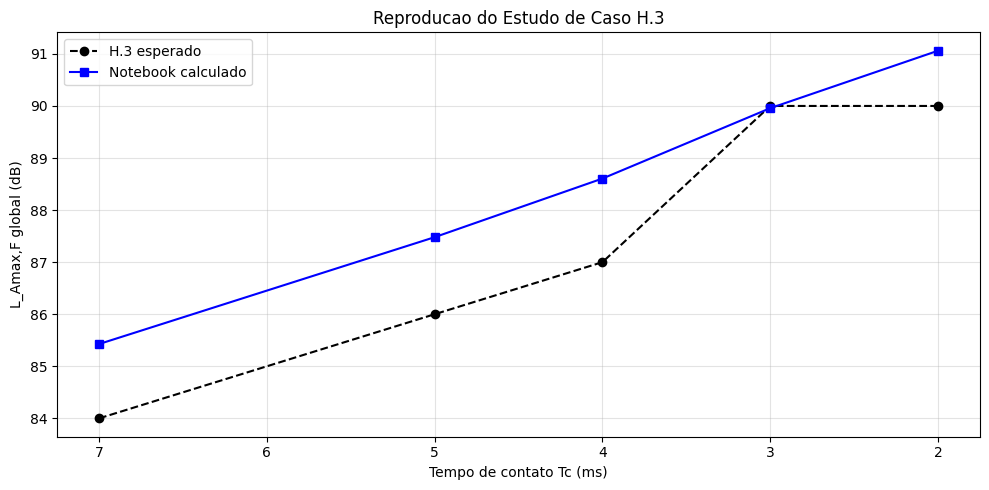

In [43]:
# ==============================================================================
# CONFERENCIA DO EXEMPLO H.3 - PROPG/GAG
# ==============================================================================

bands_validacao = np.array([31.5, 40, 50, 63, 80, 100, 125, 160, 200, 250, 315, 400, 500, 630, 800, 1000, 1250, 1600, 2000], dtype=float)
geom_h3 = geometria_cubica_equivalente(15.0)

case_h3_params = {
    "m": 35.0,
    "h": 1.0,
    "V": geom_h3["V"],
    "S_T": geom_h3["S_T"],
    "L_T": geom_h3["L_T"],
    "T60": 0.6,
    "hp": 0.25,
    "rho": 2300.0,
    "E": 30e9,
    "v_p": 0.2,
    "S_floor": geom_h3["S_floor"],
}

case_h3_targets = pd.DataFrame([
    {"Tc_ms": 2.0, "fc_esperado_Hz": 750.0, "LAmaxF_esperado_dB": 90.0},
    {"Tc_ms": 3.0, "fc_esperado_Hz": 500.0, "LAmaxF_esperado_dB": 90.0},
    {"Tc_ms": 4.0, "fc_esperado_Hz": 375.0, "LAmaxF_esperado_dB": 87.0},
    {"Tc_ms": 5.0, "fc_esperado_Hz": 300.0, "LAmaxF_esperado_dB": 86.0},
    {"Tc_ms": 7.0, "fc_esperado_Hz": 215.0, "LAmaxF_esperado_dB": 84.0},
])

rows = []
espectros_h3 = {}

for _, target in case_h3_targets.iterrows():
    Tc = target["Tc_ms"] / 1000
    espectro = []
    for freq in bands_validacao:
        calc = sea_engine_lmax(freq, **case_h3_params, Tc=Tc, return_details=True)
        espectro.append(calc)

    df_espectro = pd.DataFrame(espectro)
    espectros_h3[target["Tc_ms"]] = df_espectro
    la_global = nivel_banda_lamax_global(df_espectro["Freq_Hz"], df_espectro["Lmax_dB"], ponderacao_a=True)

    rows.append({
        "Tc_ms": target["Tc_ms"],
        "fc_calculado_Hz": contact_cutoff_hz(Tc),
        "fc_esperado_Hz": target["fc_esperado_Hz"],
        "LAmaxF_calculado_dB": la_global,
        "LAmaxF_esperado_dB": target["LAmaxF_esperado_dB"],
        "Diferenca_dB": la_global - target["LAmaxF_esperado_dB"],
        "Maior_banda_A_Hz": df_espectro.loc[(df_espectro["Lmax_dB"] + a_weighting_db(df_espectro["Freq_Hz"])).idxmax(), "Freq_Hz"],
    })

df_validacao_h3 = pd.DataFrame(rows)
display(df_validacao_h3.round(1))

max_erro = df_validacao_h3["Diferenca_dB"].abs().max()
print(f"Erro maximo absoluto: {max_erro:.1f} dB")
print("Criterio do arquivo de conferencia: dentro de +/- 6 dB.")
assert max_erro <= 6.0, "A reproducao do exemplo H.3 saiu da tolerancia +/- 6 dB."

plt.figure(figsize=(10, 5))
plt.plot(df_validacao_h3["Tc_ms"], df_validacao_h3["LAmaxF_esperado_dB"], "ko--", label="H.3 esperado")
plt.plot(df_validacao_h3["Tc_ms"], df_validacao_h3["LAmaxF_calculado_dB"], "bs-", label="Notebook calculado")
plt.gca().invert_xaxis()
plt.xlabel("Tempo de contato Tc (ms)")
plt.ylabel("L_Amax,F global (dB)")
plt.title("Reproducao do Estudo de Caso H.3")
plt.legend()
plt.tight_layout()
plt.show()


### 2. Parametros do projeto e faixa de calculo

A faixa agora termina em 2000 Hz. Essa alteracao remove a extrapolacao ate 5000 Hz que havia sido adicionada no notebook anterior sem ser necessaria para o objetivo do estudo.


In [44]:
# ==============================================================================
# 2. PARAMETROS DO PROJETO E VARIAVEIS DE TESTE
# ==============================================================================

# Carga de impacto
m = 15.0       # massa do haltere/peso em kg
h = 0.5        # altura de queda em m

# Ambiente receptor: dormitorio inferior
largura = 2.58
comprimento = 2.62
altura = 3.24

V = largura * comprimento * altura
S_floor = largura * comprimento
S_T = 2 * (largura * comprimento + largura * altura + comprimento * altura)
L_T = 4 * (largura + comprimento + altura)

# Laje e sala receptora
hp = 0.25
rho = 2400.0
E = 30e9
v_p = 0.2
T60 = 0.5

# Bandas usadas no estudo. A tabela G possui bandas acima disso, mas a predicao
# SEA deste notebook fica limitada a faixa do prompt original.
bands = np.array([31.5, 40, 50, 63, 80, 100, 125, 160, 200, 250, 315, 400, 500, 630, 800, 1000, 1250, 1600, 2000], dtype=float)

print(f"Volume: {V:.2f} m3 | Piso receptor: {S_floor:.2f} m2 | Area total: {S_T:.2f} m2 | Arestas: {L_T:.2f} m")
print(f"Espectro definido: {bands[0]} Hz a {bands[-1]} Hz ({len(bands)} bandas)")


Volume: 21.90 m3 | Piso receptor: 6.76 m2 | Area total: 47.22 m2 | Arestas: 33.76 m
Espectro definido: 31.5 Hz a 2000.0 Hz (19 bandas)


### 3. Tempo de contato e solucao de mitigacao

O tempo de contato calculado por rigidez simplificada foi mantido apenas como estudo de sensibilidade. A interpretacao correta e: quanto maior o `Tc`, menor o cutoff de contato e menor a excitacao em bandas acima desse corte. Isso nao prova desempenho sem ensaio.


In [45]:
# ==============================================================================
# 3. TEMPO DE CONTATO - FUNCAO EXPLICITA E DIAGNOSTICO
# ==============================================================================

def calcular_tc_analitico(m_proj, E_proj, d_proj, tipo_material="macio", r=0.05, v=0.3, return_details=False):
    """
    Estimativa simplificada de tempo de contato.

    Alteracao feita: a funcao nao usa mais variaveis globais do notebook. Isso
    evita que uma celula executada fora de ordem use massa, modulo ou espessura
    errados sem aviso.
    """
    for name, value in {"m_proj": m_proj, "E_proj": E_proj, "d_proj": d_proj, "r": r}.items():
        if value <= 0:
            raise ValueError(f"{name} deve ser maior que zero.")

    if tipo_material == "macio":
        stiffness = (E_proj * np.pi * r**2) / d_proj
    elif tipo_material == "rigido":
        stiffness = (2 * r * E_proj) / (1 - v**2)
    else:
        raise ValueError("tipo_material deve ser 'macio' ou 'rigido'.")

    Tc = np.pi * np.sqrt(m_proj / stiffness)
    details = {
        "Tc_s": Tc,
        "Tc_ms": Tc * 1000,
        "Rigidez_contato_N_m": stiffness,
        "fc_contato_Hz": contact_cutoff_hz(Tc),
    }
    return details if return_details else Tc


def aviso_tc(Tc):
    if Tc < 0.002:
        return "Tc abaixo de 2 ms: valor muito rigido; calibrar com ensaio ou referencia ProPG."
    if Tc > 0.030:
        return "Tc acima de 30 ms: forte extrapolacao para este estudo; nao usar como conclusao de projeto."
    if Tc > 0.007:
        return "Tc acima dos 2-7 ms dos exemplos ProPG revisados; tratar como sensibilidade do material, nao como dado validado."
    return "Tc dentro da faixa 2-7 ms usada nos exemplos ProPG revisados."


In [46]:
# ==============================================================================
# 4. CONFIGURACAO DA SOLUCAO
# ==============================================================================

material_resiliente = {
    "nome": "EVA espesso",
    "E_dinamico_Pa": 5e6,
    "espessura_m": 0.04,
    "tipo": "macio",
}

# Alteracao feita: a laje nua nao usa mais o modelo rigido simplificado, que dava
# Tc artificialmente muito baixo. Adota-se um valor de estudo dentro da faixa dos
# exemplos ProPG (2-7 ms) e deixa-se claro que deve ser calibrado.
Tc_original = 0.003

contact_details = calcular_tc_analitico(
    m_proj=m,
    E_proj=material_resiliente["E_dinamico_Pa"],
    d_proj=material_resiliente["espessura_m"],
    tipo_material=material_resiliente["tipo"],
    return_details=True,
)
Tc_mitigado = contact_details["Tc_s"]

# Piso flutuante: parametros de estudo, nao dados de fornecedor.
fn_molas = 6.0
zeta_molas = 0.08
cap_atenuacao = 24.0

print(f"Solucao: {material_resiliente['nome']}")
print(f"Tc original adotado: {Tc_original*1000:.2f} ms | fc = {contact_cutoff_hz(Tc_original):.0f} Hz | {aviso_tc(Tc_original)}")
print(f"Tc mitigado estimado: {Tc_mitigado*1000:.2f} ms | fc = {contact_details['fc_contato_Hz']:.0f} Hz | {aviso_tc(Tc_mitigado)}")
print(f"Rigidez de contato estimada: {contact_details['Rigidez_contato_N_m']:.2e} N/m")
print(f"SDOF: fn = {fn_molas:.1f} Hz | zeta = {zeta_molas:.2f} | cap = {cap_atenuacao:.1f} dB")


Solucao: EVA espesso
Tc original adotado: 3.00 ms | fc = 500 Hz | Tc dentro da faixa 2-7 ms usada nos exemplos ProPG revisados.
Tc mitigado estimado: 12.28 ms | fc = 122 Hz | Tc acima dos 2-7 ms dos exemplos ProPG revisados; tratar como sensibilidade do material, nao como dado validado.
Rigidez de contato estimada: 9.82e+05 N/m
SDOF: fn = 6.0 Hz | zeta = 0.08 | cap = 24.0 dB


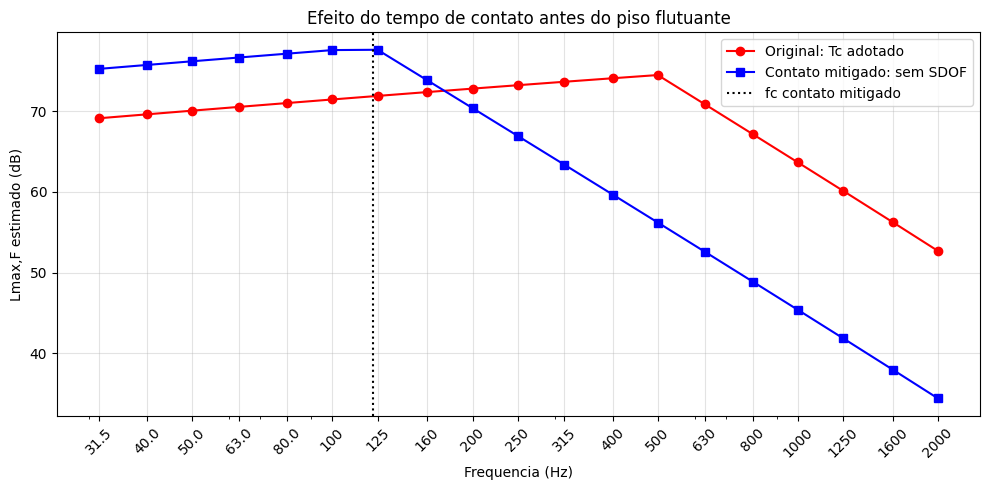

,Freq_Hz,Lmax_original_dB,Lmax_com_Tc_mitigado_dB,fc_mitigado_Hz,Correcao_contato_dB,M,Avisos_SEA
0,31.5,69.1,75.2,122.2,0.0,0.2,M<1: SEA pouco robusto nesta banda
1,40.0,69.6,75.7,122.2,0.0,0.2,M<1: SEA pouco robusto nesta banda
2,50.0,70.1,76.2,122.2,0.0,0.3,M<1: SEA pouco robusto nesta banda
3,63.0,70.5,76.7,122.2,0.0,0.3,M<1: SEA pouco robusto nesta banda
4,80.0,71.0,77.1,122.2,0.0,0.5,M<1: SEA pouco robusto nesta banda
5,100.0,71.5,77.6,122.2,0.0,0.6,M<1: SEA pouco robusto nesta banda
6,125.0,71.9,77.6,122.2,-0.4,0.9,M<1: SEA pouco robusto nesta banda; banda acim...
7,160.0,72.4,73.8,122.2,-4.7,1.3,banda acima do cutoff de contato
8,200.0,72.8,70.4,122.2,-8.5,1.8,banda acima do cutoff de contato
9,250.0,73.2,66.9,122.2,-12.4,2.6,banda acima do cutoff de contato


In [47]:
# ==============================================================================
# 4.1. EFEITO ISOLADO DO TEMPO DE CONTATO
# ==============================================================================
# Esta etapa mostra apenas a mudanca causada pelo Tc, antes da atenuacao SDOF.

results_lmax = []

for freq in bands:
    original = sea_engine_lmax(freq, m, h, V, S_T, L_T, T60, hp, rho, E, v_p, Tc_original, S_floor=S_floor, return_details=True)
    contato = sea_engine_lmax(freq, m, h, V, S_T, L_T, T60, hp, rho, E, v_p, Tc_mitigado, S_floor=S_floor, return_details=True)
    results_lmax.append({
        "Freq_Hz": freq,
        "Lmax_original_dB": original["Lmax_dB"],
        "Lmax_com_Tc_mitigado_dB": contato["Lmax_dB"],
        "fc_mitigado_Hz": contato["fc_contato_Hz"],
        "Correcao_contato_dB": contato["Correcao_contato_dB"],
        "M": contato["M"],
        "Avisos_SEA": contato["Avisos_SEA"],
    })

df_lmax = pd.DataFrame(results_lmax)

plt.figure(figsize=(10, 5))
plt.semilogx(df_lmax["Freq_Hz"], df_lmax["Lmax_original_dB"], "r-o", label="Original: Tc adotado")
plt.semilogx(df_lmax["Freq_Hz"], df_lmax["Lmax_com_Tc_mitigado_dB"], "b-s", label="Contato mitigado: sem SDOF")
plt.axvline(contact_cutoff_hz(Tc_mitigado), color="black", linestyle=":", label="fc contato mitigado")
plt.xticks(bands, [str(int(f)) if f >= 100 else str(f) for f in bands], rotation=45)
plt.xlabel("Frequencia (Hz)")
plt.ylabel("Lmax,F estimado (dB)")
plt.title("Efeito do tempo de contato antes do piso flutuante")
plt.legend()
plt.tight_layout()
plt.show()

display(df_lmax.round(1))


### 5. Execucao e relatorio revisados

As proximas celulas empacotam os parametros, classificam por Curva G e exibem os avisos tecnicos por banda.


In [48]:
# ==============================================================================
# EMPACOTAMENTO DE VARIAVEIS PARA O MOTOR DE CALCULO
# ==============================================================================

input_params = {
    "m": m,
    "h": h,
    "V": V,
    "S_T": S_T,
    "L_T": L_T,
    "T60": T60,
    "hp": hp,
    "rho": rho,
    "E": E,
    "v_p": v_p,
    "S_floor": S_floor,
}

solution_params = {
    "Tc_original": Tc_original,
    "Tc_mitigado": Tc_mitigado,
    "fn_molas": fn_molas,
    "zeta_molas": zeta_molas,
    "cap_db": cap_atenuacao,
}

print(f"Tc original adotado: {solution_params['Tc_original']*1000:.2f} ms")
print(f"Tc mitigado estimado: {solution_params['Tc_mitigado']*1000:.2f} ms")
print("Nota: ambos devem ser substituidos por medicao/calibracao antes de decisao executiva.")


Tc original adotado: 3.00 ms
Tc mitigado estimado: 12.28 ms
Nota: ambos devem ser substituidos por medicao/calibracao antes de decisao executiva.


In [49]:
# ==============================================================================
# CLASSIFICACAO POR CURVAS G
# ==============================================================================

def _matching_g_frequency_column(f_val, df_referencia, tol=1e-6):
    for col in g_curve_frequency_columns(df_referencia):
        if abs(float(col) - float(f_val)) <= tol:
            return col
    return None


def limite_curva_g(f_val, g_value, df_referencia=df_reported):
    col = _matching_g_frequency_column(f_val, df_referencia)
    if col is None:
        return np.nan
    row = df_referencia.loc[df_referencia["G-value"] == g_value]
    if row.empty:
        return np.nan
    return float(row.iloc[0][col])


def classificar_curva_g(f_val, lmax_val, df_referencia=df_reported):
    """
    Retorna a primeira Curva G atendida pela banda.

    Alteracao feita: a classificacao agora usa colunas numericas e informa quando
    a frequencia nao existe na tabela, em vez de depender de strings com virgula.
    """
    col = _matching_g_frequency_column(f_val, df_referencia)
    if col is None:
        return "sem curva G"

    for _, row in df_referencia.sort_values("G-value").iterrows():
        limite = float(row[col])
        if lmax_val <= limite:
            return f"G{int(row['G-value'])}"
    return "> G50"

print("Classificador G carregado.")


Classificador G carregado.


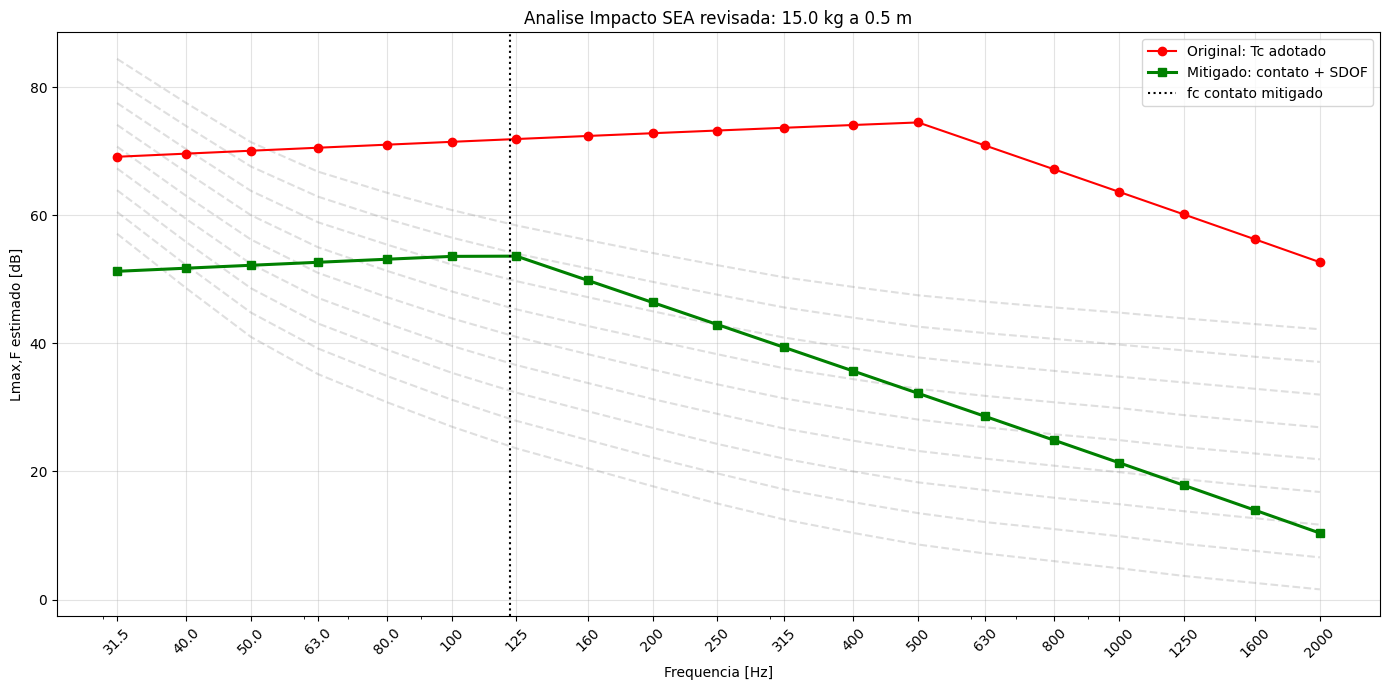

,Freq_Hz,Lmax_original_dB,Lmax_contato_mitigado_dB,Atenuacao_SDOF_dB,Lmax_mitigado_dB,Classificacao_G,Correcao_contato_dB,M,Avisos
0,31.5,69.1,75.2,24.0,51.2,G10,0.0,0.2,original: M<1: SEA pouco robusto nesta banda; ...
1,40.0,69.6,75.7,24.0,51.7,G15,0.0,0.2,original: M<1: SEA pouco robusto nesta banda; ...
2,50.0,70.1,76.2,24.0,52.2,G25,0.0,0.3,original: M<1: SEA pouco robusto nesta banda; ...
3,63.0,70.5,76.7,24.0,52.7,G35,0.0,0.3,original: M<1: SEA pouco robusto nesta banda; ...
4,80.0,71.0,77.1,24.0,53.1,G40,0.0,0.5,original: M<1: SEA pouco robusto nesta banda; ...
5,100.0,71.5,77.6,24.0,53.6,G45,0.0,0.6,original: M<1: SEA pouco robusto nesta banda; ...
6,125.0,71.9,77.6,24.0,53.6,G45,-0.4,0.9,original: M<1: SEA pouco robusto nesta banda; ...
7,160.0,72.4,73.8,24.0,49.8,G45,-4.7,1.3,mitigado: banda acima do cutoff de contato; ca...
8,200.0,72.8,70.4,24.0,46.4,G45,-8.5,1.8,mitigado: banda acima do cutoff de contato; ca...
9,250.0,73.2,66.9,24.0,42.9,G45,-12.4,2.6,mitigado: banda acima do cutoff de contato; ca...


### Tabela de resultados revisada
| Freq [Hz] | Lmax original [dB] | Lmax mitigado [dB] | Atenuacao SDOF [dB] | Curva G | Avisos |
| :--- | :--- | :--- | :--- | :--- | :--- |
| 31.5 | 69.1 | 51.2 | 24.0 | G10 | original: M<1: SEA pouco robusto nesta banda; mitigado: M<1: SEA pouco robusto nesta banda; cap SDOF ativo |
| 40.0 | 69.6 | 51.7 | 24.0 | G15 | original: M<1: SEA pouco robusto nesta banda; mitigado: M<1: SEA pouco robusto nesta banda; cap SDOF ativo |
| 50.0 | 70.1 | 52.2 | 24.0 | G25 | original: M<1: SEA pouco robusto nesta banda; mitigado: M<1: SEA pouco robusto nesta banda; cap SDOF ativo |
| 63.0 | 70.5 | 52.7 | 24.0 | G35 | original: M<1: SEA pouco robusto nesta banda; mitigado: M<1: SEA pouco robusto nesta banda; cap SDOF ativo |
| 80.0 | 71.0 | 53.1 | 24.0 | G40 | original: M<1: SEA pouco robusto nesta banda; mitigado: M<1: SEA pouco robusto nesta banda; cap SDOF ativo |
| 100.0 | 71.5 | 53.6 | 24.0 | G45 | original: M<1: SEA pouco robusto nesta banda; mitigado: M<1: SEA pouco robusto nesta banda; cap SDOF ativo |
| 125.0 | 71.9 | 53.6 | 24.0 | G45 | original: M<1: SEA pouco robusto nesta banda; mitigado: M<1: SEA pouco robusto nesta banda; banda acima do cutoff de contato; cap SDOF ativo |
| 160.0 | 72.4 | 49.8 | 24.0 | G45 | mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 200.0 | 72.8 | 46.4 | 24.0 | G45 | mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 250.0 | 73.2 | 42.9 | 24.0 | G45 | mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 315.0 | 73.6 | 39.4 | 24.0 | G40 | mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 400.0 | 74.1 | 35.7 | 24.0 | G40 | mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 500.0 | 74.5 | 32.2 | 24.0 | G35 | mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 630.0 | 70.9 | 28.6 | 24.0 | G35 | original: banda acima do cutoff de contato; mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 800.0 | 67.1 | 24.9 | 24.0 | G30 | original: banda acima do cutoff de contato; mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 1000.0 | 63.6 | 21.4 | 24.0 | G30 | original: banda acima do cutoff de contato; mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 1250.0 | 60.1 | 17.9 | 24.0 | G25 | original: banda acima do cutoff de contato; mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 1600.0 | 56.2 | 13.9 | 24.0 | G25 | original: banda acima do cutoff de contato; mitigado: banda acima do cutoff de contato; cap SDOF ativo |
| 2000.0 | 52.7 | 10.4 | 24.0 | G20 | original: banda acima do cutoff de contato; mitigado: banda acima do cutoff de contato; cap SDOF ativo |


In [50]:
# ==============================================================================
# 5. PROCESSAMENTO FINAL E COMPARACAO COM CURVAS G
# ==============================================================================

results = []

for f in bands:
    original = sea_engine_lmax(f, **input_params, Tc=solution_params["Tc_original"], return_details=True)
    contato = sea_engine_lmax(f, **input_params, Tc=solution_params["Tc_mitigado"], return_details=True)
    sdof = sdof_attenuation(
        f,
        solution_params["fn_molas"],
        zeta=solution_params["zeta_molas"],
        cap=solution_params["cap_db"],
        return_details=True,
    )

    lmax_mitigado = contato["Lmax_dB"] - sdof["Atenuacao_SDOF_dB"]
    curva_atendida = classificar_curva_g(f, lmax_mitigado, df_reported)

    avisos = []
    for key in ["Avisos_SEA"]:
        if original[key]:
            avisos.append(f"original: {original[key]}")
        if contato[key]:
            avisos.append(f"mitigado: {contato[key]}")
    if sdof["Cap_SDOF_ativo"]:
        avisos.append("cap SDOF ativo")
    if sdof["Proximo_ressonancia"]:
        avisos.append("proximo da ressonancia SDOF")

    results.append({
        "Freq_Hz": f,
        "Lmax_original_dB": original["Lmax_dB"],
        "Lmax_contato_mitigado_dB": contato["Lmax_dB"],
        "Atenuacao_SDOF_dB": sdof["Atenuacao_SDOF_dB"],
        "Lmax_mitigado_dB": lmax_mitigado,
        "Classificacao_G": curva_atendida,
        "fc_contato_mitigado_Hz": contato["fc_contato_Hz"],
        "Correcao_contato_dB": contato["Correcao_contato_dB"],
        "M": contato["M"],
        "Lv_indicativo_dB": contato["Lv_indicativo_dB"],
        "Avisos": "; ".join(avisos),
    })

df_final = pd.DataFrame(results)

plt.figure(figsize=(14, 7))
plot_cols = [f for f in g_curve_frequency_columns(df_reported) if f in set(bands)]
for _, g_row in df_reported.iterrows():
    plt.semilogx(plot_cols, [g_row[f] for f in plot_cols], "--", alpha=0.25, color="gray")

plt.semilogx(df_final["Freq_Hz"], df_final["Lmax_original_dB"], "r-o", label="Original: Tc adotado", linewidth=1.5)
plt.semilogx(df_final["Freq_Hz"], df_final["Lmax_mitigado_dB"], "g-s", label="Mitigado: contato + SDOF", linewidth=2.2)
plt.axvline(contact_cutoff_hz(Tc_mitigado), color="black", linestyle=":", label="fc contato mitigado")
plt.xticks(bands, labels=[str(int(b)) if b >= 100 else str(b) for b in bands], rotation=45)
plt.title(f"Analise Impacto SEA revisada: {input_params['m']} kg a {input_params['h']} m")
plt.ylabel("Lmax,F estimado [dB]")
plt.xlabel("Frequencia [Hz]")
plt.legend()
plt.tight_layout()
plt.show()

cols_show = [
    "Freq_Hz",
    "Lmax_original_dB",
    "Lmax_contato_mitigado_dB",
    "Atenuacao_SDOF_dB",
    "Lmax_mitigado_dB",
    "Classificacao_G",
    "Correcao_contato_dB",
    "M",
    "Avisos",
]
display(df_final[cols_show].round(1))

markdown_table = "### Tabela de resultados revisada\n"
markdown_table += "| Freq [Hz] | Lmax original [dB] | Lmax mitigado [dB] | Atenuacao SDOF [dB] | Curva G | Avisos |\n"
markdown_table += "| :--- | :--- | :--- | :--- | :--- | :--- |\n"
for _, row in df_final.iterrows():
    avisos = row["Avisos"] if row["Avisos"] else "-"
    markdown_table += f"| {row['Freq_Hz']:.1f} | {row['Lmax_original_dB']:.1f} | {row['Lmax_mitigado_dB']:.1f} | {row['Atenuacao_SDOF_dB']:.1f} | {row['Classificacao_G']} | {avisos} |\n"

display(Markdown(markdown_table))


## Analise revisada dos resultados

A interpretacao anterior era otimista em um ponto e pessimista em outro.

- Era otimista porque usava 35 dB como teto fixo de atenuacao do piso flutuante. Nos documentos revisados, os exemplos medidos de sistemas com mola e manta ficam mais proximos de 17-24 dBA de reducao global. Por isso o padrao do estudo agora e 24 dB, ate que exista ensaio do sistema real.
- Era pessimista nas medias/altas frequencias porque o tempo de contato nao produzia uma frequencia de corte efetiva. Agora as bandas acima de `fc = 1,5/Tc` sao reduzidas a `-12 dB/oitava` e marcadas como pos-cutoff.
- O resultado que importa para decisao nao e apenas a menor curva G de uma banda isolada. E necessario observar os avisos de `M<1`, a faixa de baixa frequencia, o cutoff de contato e se o cap SDOF foi acionado.
- O `Tc` estimado para o EVA vem de um modelo mecanico simplificado. Se esse valor for usado para defender desempenho de projeto, ele precisa ser substituido por dado medido do conjunto peso + superficie + piso flutuante.

Conclusao tecnica desta revisao: o notebook agora e mais adequado para triagem e sensibilidade. Ele ainda nao deve ser usado como laudo ou promessa de atendimento ProPG/ProAcustica sem ensaio de impacto/vibracao no sistema construtivo real.


In [51]:
# ==============================================================================
# 6. INDICADORES GLOBAIS E BAIXA FREQUENCIA
# ==============================================================================

def soma_logaritmica(niveis_banda):
    """Soma logaritmica de niveis em dB."""
    niveis = np.asarray(niveis_banda, dtype=float)
    return 10 * np.log10(np.sum(10 ** (niveis / 10)))


def calcular_lfispl(df, coluna_nivel, bandas_lf=(50.0, 63.0, 80.0)):
    """
    Indicador complementar de baixa frequencia baseado nas bandas 50, 63 e 80 Hz.

    Alteracao feita: foi adicionada uma leitura de LFISPL/LIR porque a literatura
    de impacto em baixa frequencia mostra melhor correlacao com incomodidade do
    que numeros globais convencionais. Use como triagem, nao como norma local.
    """
    subset = df.loc[df["Freq_Hz"].isin(bandas_lf), coluna_nivel]
    if len(subset) != len(bandas_lf):
        missing = set(bandas_lf) - set(df.loc[df["Freq_Hz"].isin(bandas_lf), "Freq_Hz"])
        raise ValueError(f"Bandas LF ausentes: {sorted(missing)}")
    return soma_logaritmica(subset)


def calcular_lir(lfispl):
    return 190 - 2 * lfispl

if "df_final" in locals():
    lmax_global_original = soma_logaritmica(df_final["Lmax_original_dB"])
    lmax_global_mitigado = soma_logaritmica(df_final["Lmax_mitigado_dB"])
    lfispl_original = calcular_lfispl(df_final, "Lmax_original_dB")
    lfispl_mitigado = calcular_lfispl(df_final, "Lmax_mitigado_dB")

    resumo = pd.DataFrame([
        {"Indicador": "Soma log Lmax por banda", "Original": lmax_global_original, "Mitigado": lmax_global_mitigado, "Reducao": lmax_global_original - lmax_global_mitigado},
        {"Indicador": "LFISPL 50+63+80 Hz", "Original": lfispl_original, "Mitigado": lfispl_mitigado, "Reducao": lfispl_original - lfispl_mitigado},
        {"Indicador": "LIR = 190 - 2*LFISPL", "Original": calcular_lir(lfispl_original), "Mitigado": calcular_lir(lfispl_mitigado), "Reducao": calcular_lir(lfispl_mitigado) - calcular_lir(lfispl_original)},
    ])
    display(resumo.round(1))

    print("Nota: a primeira linha nao e Leq. E apenas soma logaritmica de Lmax por banda para comparacao interna do estudo.")
else:
    print("Execute a etapa 5 antes de calcular os indicadores finais.")


,Indicador,Original,Mitigado,Reducao
0,Soma log Lmax por banda,83.7,61.7,22.1
1,LFISPL 50+63+80 Hz,75.3,57.4,17.9
2,LIR = 190 - 2*LFISPL,39.4,75.1,35.8


Nota: a primeira linha nao e Leq. E apenas soma logaritmica de Lmax por banda para comparacao interna do estudo.
